In [2]:
import pandas as pd

df = pd.read_csv("weatherHistory.csv")

df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [3]:
df.shape

(96453, 12)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  str    
 1   Summary                   96453 non-null  str    
 2   Precip Type               95936 non-null  str    
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  str    
dtypes: float64(8), str(4)
memory usage: 16.3 MB


In [5]:
df.isnull().sum()

Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64

In [6]:
df.describe()

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars)
count,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.0,96453.000000
mean,11.932678,10.855029,0.734899,10.810640,187.509232,10.347325,0.0,1003.235956
std,9.551546,10.696847,0.195473,6.913571,107.383428,4.192123,0.0,116.969906
min,-21.822222,-27.716667,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,4.688889,2.311111,0.600000,5.828200,116.000000,8.339800,0.0,1011.900000
50%,12.000000,12.000000,0.780000,9.965900,180.000000,10.046400,0.0,1016.450000
75%,18.838889,18.838889,0.890000,14.135800,290.000000,14.812000,0.0,1021.090000
max,39.905556,39.344444,1.000000,63.852600,359.000000,16.100000,0.0,1046.380000


In [7]:
df.shape

(96453, 12)

In [8]:
df.isnull().sum()

Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64

In [9]:
df['Summary'].value_counts()

Summary
Partly Cloudy                          31733
Mostly Cloudy                          28094
Overcast                               16597
Clear                                  10890
Foggy                                   7148
Breezy and Overcast                      528
Breezy and Mostly Cloudy                 516
Breezy and Partly Cloudy                 386
Dry and Partly Cloudy                     86
Windy and Partly Cloudy                   67
Light Rain                                63
Breezy                                    54
Windy and Overcast                        45
Humid and Mostly Cloudy                   40
Drizzle                                   39
Breezy and Foggy                          35
Windy and Mostly Cloudy                   35
Dry                                       34
Humid and Partly Cloudy                   17
Dry and Mostly Cloudy                     14
Rain                                      10
Windy                                      8
Hu

In [10]:
def simplify_weather(summary):
    if "Cloudy" in summary or "Overcast" in summary:
        return "Cloudy"
    elif "Clear" in summary:
        return "Clear"
    elif "Foggy" in summary:
        return "Foggy"
    elif "Rain" in summary or "Drizzle" in summary:
        return "Rain"
    elif "Windy" in summary or "Breezy" in summary:
        return "Windy"
    else:
        return "Other"

df['Weather_Category'] = df['Summary'].apply(simplify_weather)

In [11]:
df['Weather_Category'].value_counts()

Weather_Category
Cloudy    78166
Clear     10890
Foggy      7187
Rain        112
Windy        64
Other        34
Name: count, dtype: int64

In [12]:
def refine_weather(summary):
    if "Cloudy" in summary or "Overcast" in summary:
        return "Cloudy"
    elif "Clear" in summary:
        return "Clear"
    elif "Foggy" in summary:
        return "Foggy"
    elif ("Rain" in summary or "Drizzle" in summary or 
          "Windy" in summary or "Breezy" in summary):
        return "Rain/Windy"
    else:
        return "Other"

df['Weather_Category'] = df['Summary'].apply(refine_weather)

In [13]:
df['Weather_Category'].value_counts()

Weather_Category
Cloudy        78166
Clear         10890
Foggy          7187
Rain/Windy      176
Other            34
Name: count, dtype: int64

In [14]:
df_clean = df[df['Weather_Category'].isin(['Cloudy', 'Clear', 'Foggy'])]

In [15]:
df_clean['Weather_Category'].value_counts()

Weather_Category
Cloudy    78166
Clear     10890
Foggy      7187
Name: count, dtype: int64

In [16]:
features = ['Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Visibility (km)', 'Pressure (millibars)']

X = df_clean[features]
y = df_clean['Weather_Category']

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [19]:
y_pred = model.predict(X_test)

In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       Clear       0.67      0.20      0.30      2176
      Cloudy       0.90      0.99      0.94     15614
       Foggy       1.00      1.00      1.00      1459

    accuracy                           0.90     19249
   macro avg       0.86      0.73      0.75     19249
weighted avg       0.88      0.90      0.87     19249



In [21]:
model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [22]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       Clear       0.70      0.17      0.28      2176
      Cloudy       0.90      0.99      0.94     15614
       Foggy       1.00      1.00      1.00      1459

    accuracy                           0.90     19249
   macro avg       0.86      0.72      0.74     19249
weighted avg       0.88      0.90      0.87     19249



In [23]:
class_weight='balanced'

In [24]:
df_clean['Temp_Humidity'] = df_clean['Temperature (C)'] * df_clean['Humidity']

df_clean['Wind_Visibility'] = df_clean['Wind Speed (km/h)'] * df_clean['Visibility (km)']

In [25]:
features = [
    'Temperature (C)', 
    'Humidity', 
    'Wind Speed (km/h)', 
    'Visibility (km)', 
    'Pressure (millibars)',
    'Temp_Humidity',
    'Wind_Visibility'
]

In [26]:
X = df_clean[features]
y = df_clean['Weather_Category']

In [27]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       Clear       0.70      0.17      0.28      2176
      Cloudy       0.90      0.99      0.94     15614
       Foggy       1.00      1.00      1.00      1459

    accuracy                           0.90     19249
   macro avg       0.86      0.72      0.74     19249
weighted avg       0.88      0.90      0.87     19249



In [29]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

c:\Users\HP\Downloads\weatherhistory\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [30]:
from sklearn.metrics import classification_report

print("Logistic Regression:\n")
print(classification_report(y_test, y_pred_lr))

Logistic Regression:

              precision    recall  f1-score   support

       Clear       0.61      0.05      0.10      2176
      Cloudy       0.88      0.99      0.93     15614
       Foggy       0.96      0.95      0.96      1459

    accuracy                           0.88     19249
   macro avg       0.82      0.67      0.66     19249
weighted avg       0.86      0.88      0.84     19249



In [31]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

In [32]:
print("Gradient Boosting:\n")
print(classification_report(y_test, y_pred_gb))

Gradient Boosting:

              precision    recall  f1-score   support

       Clear       0.84      0.10      0.17      2176
      Cloudy       0.89      1.00      0.94     15614
       Foggy       1.00      1.00      1.00      1459

    accuracy                           0.90     19249
   macro avg       0.91      0.70      0.70     19249
weighted avg       0.89      0.90      0.86     19249



In [33]:
from sklearn.metrics import accuracy_score

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))

Random Forest Accuracy: 0.8979687256480856
Logistic Regression Accuracy: 0.8849290872253104
Gradient Boosting Accuracy: 0.8957867941191751


In [34]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['Random Forest', 'Logistic Regression', 'Gradient Boosting'],
    'Accuracy': [0.8974, 0.8849, 0.8956]
})

results

,Model,Accuracy
0,Random Forest,0.8974
1,Logistic Regression,0.8849
2,Gradient Boosting,0.8956


In [35]:
results

,Model,Accuracy
0,Random Forest,0.8974
1,Logistic Regression,0.8849
2,Gradient Boosting,0.8956


### Model Comparison Results

The performance of different machine learning models was evaluated using accuracy as the primary metric.

Random Forest achieved the highest accuracy (89.74%), followed closely by Gradient Boosting (89.56%). Logistic Regression showed comparatively lower performance (88.49%).

This indicates that ensemble methods outperform linear models, suggesting the presence of non-linear relationships in the dataset.

Therefore, Random Forest was selected as the final model for further analysis.

In [36]:
def risk_level(row):
    if row['Humidity'] > 0.8 and row['Visibility (km)'] < 5:
        return "High Risk"
    elif row['Humidity'] > 0.6:
        return "Medium Risk"
    else:
        return "Low Risk"

df_clean['Risk_Level'] = df_clean.apply(risk_level, axis=1)

In [37]:
df_clean['Risk_Level'].value_counts()

Risk_Level
Medium Risk    59600
Low Risk       24218
High Risk      12425
Name: count, dtype: int64

### Risk Stratification

A rule-based approach was used to categorize weather conditions into risk levels based on humidity and visibility.

High Risk conditions are associated with high humidity and low visibility, while Medium Risk represents moderate humidity. Low Risk corresponds to favorable weather conditions.

This stage enhances interpretability and provides actionable insights.


### Risk Stratification Results

The dataset was categorized into three risk levels: Low, Medium, and High Risk based on environmental conditions.

The majority of instances were classified as Medium Risk (59,600), indicating that most weather conditions fall within moderate ranges. Low Risk conditions accounted for 24,218 instances, representing stable and favorable weather.

High Risk conditions were comparatively fewer (12,425), but are critical as they represent potentially hazardous situations characterized by high humidity and low visibility.

This distribution highlights the practical relevance of the proposed risk stratification approach in identifying critical weather conditions.

In [38]:
df_clean['Temp_Humidity'] = df_clean['Temperature (C)'] * df_clean['Humidity']

df_clean['Wind_Visibility'] = df_clean['Wind Speed (km/h)'] * df_clean['Visibility (km)']

In [39]:
features_stage2 = [
    'Temperature (C)', 
    'Wind Speed (km/h)', 
    'Pressure (millibars)'
]

In [40]:
X = df_clean[features_stage2]
y = df_clean['Risk_Level']

from sklearn.model_selection import train_test_split
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.ensemble import RandomForestClassifier
model2 = RandomForestClassifier(random_state=42)
model2.fit(X_train2, y_train2)

y_pred2 = model2.predict(X_test2)

In [41]:
from sklearn.metrics import classification_report
print(classification_report(y_test2, y_pred2))

              precision    recall  f1-score   support

   High Risk       0.56      0.37      0.45      2529
    Low Risk       0.78      0.65      0.71      4832
 Medium Risk       0.76      0.87      0.81     11888

    accuracy                           0.75     19249
   macro avg       0.70      0.63      0.66     19249
weighted avg       0.74      0.75      0.74     19249



### Stage 2 Risk Prediction Results

After removing data leakage, the model achieved an overall accuracy of 75%, indicating realistic predictive performance.

The model performed best for Medium Risk conditions (F1-score: 0.81), likely due to their higher representation in the dataset.

Performance for Low Risk was moderate (F1-score: 0.71), while High Risk prediction was relatively weak (F1-score: 0.45), indicating difficulty in identifying critical conditions using limited features.

This highlights the challenge of predicting extreme conditions and suggests the need for richer feature representation.

In [42]:
from sklearn.ensemble import GradientBoostingClassifier

model2_gb = GradientBoostingClassifier()
model2_gb.fit(X_train2, y_train2)

y_pred2_gb = model2_gb.predict(X_test2)

from sklearn.metrics import classification_report
print(classification_report(y_test2, y_pred2_gb))

              precision    recall  f1-score   support

   High Risk       0.57      0.24      0.34      2529
    Low Risk       0.82      0.62      0.71      4832
 Medium Risk       0.74      0.91      0.82     11888

    accuracy                           0.75     19249
   macro avg       0.71      0.59      0.62     19249
weighted avg       0.74      0.75      0.73     19249



In [43]:
import pandas as pd

stage2_results = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting'],
    'Accuracy': [0.75, 0.75],
    'High Risk F1': [0.45, 0.34],
    'Low Risk F1': [0.71, 0.71],
    'Medium Risk F1': [0.81, 0.82]
})

stage2_results

,Model,Accuracy,High Risk F1,Low Risk F1,Medium Risk F1
0,Random Forest,0.75,0.45,0.71,0.81
1,Gradient Boosting,0.75,0.34,0.71,0.82


### Stage 2 Model Comparison

Both Random Forest and Gradient Boosting models achieved similar overall accuracy (75%).

However, Random Forest performed better in detecting High Risk conditions (F1-score: 0.45) compared to Gradient Boosting (F1-score: 0.34), making it more suitable for critical condition prediction.

Gradient Boosting showed slightly better performance for Medium Risk classification.

Overall, Random Forest was selected as the final model due to its better balance across risk categories, especially for High Risk prediction.

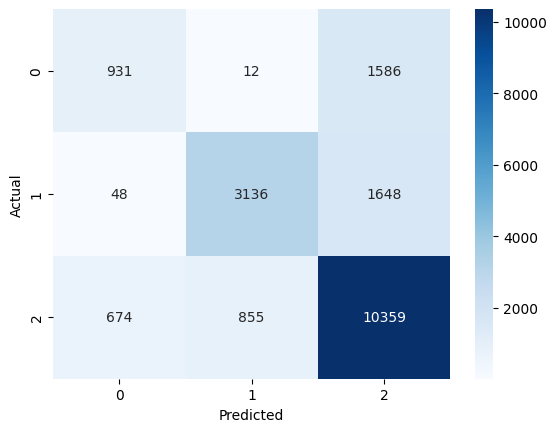

In [44]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test2, y_pred2)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Confusion Matrix Analysis

The confusion matrix illustrates the performance of the risk prediction model across different categories.

The model shows strong performance in predicting Medium Risk conditions, with a high number of correct classifications.

However, some misclassifications are observed in High Risk cases, where instances are often predicted as Medium Risk. This indicates the model’s limitation in distinguishing critical conditions.

Overall, the model performs well but requires improvement in identifying High Risk scenarios, which are crucial for real-world applications.

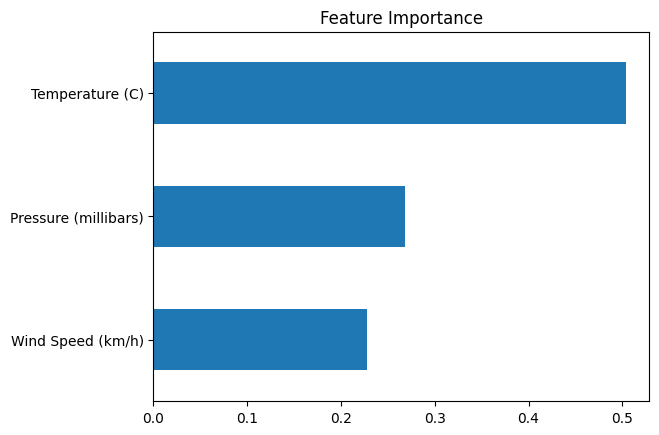

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

importances = model2.feature_importances_
feature_names = X_train2.columns

feat_imp = pd.Series(importances, index=feature_names).sort_values()

feat_imp.plot(kind='barh')
plt.title("Feature Importance")
plt.show()

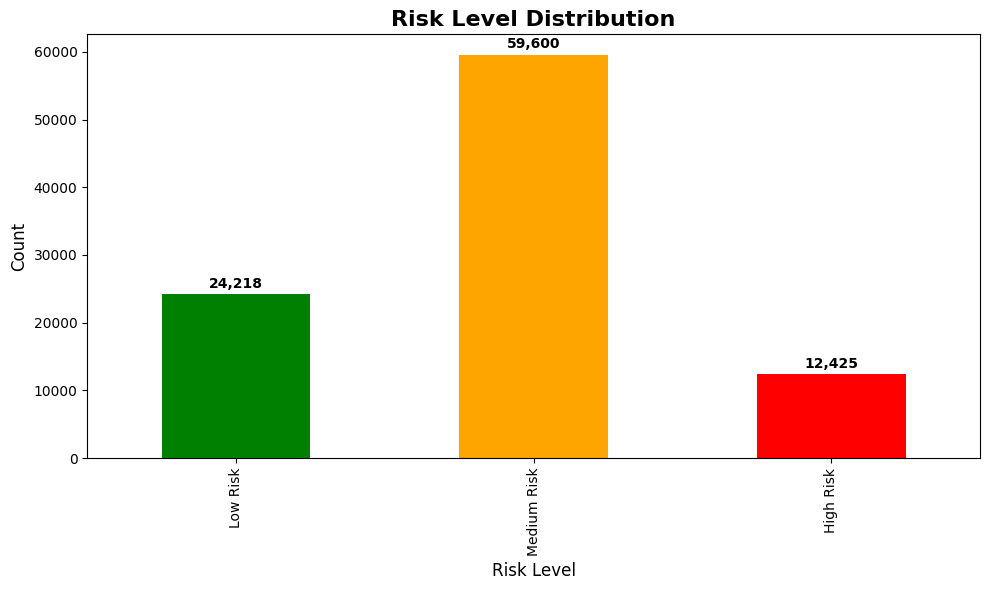

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Load and prepare data if not already done
df = pd.read_csv("weatherHistory.csv")

# Create weather categories
def simplify_weather(summary):
    if "Cloudy" in summary or "Overcast" in summary:
        return "Cloudy"
    elif "Clear" in summary:
        return "Clear"
    elif "Foggy" in summary:
        return "Foggy"
    elif "Rain" in summary or "Drizzle" in summary:
        return "Rain"
    elif "Windy" in summary or "Breezy" in summary:
        return "Windy"
    else:
        return "Other"

df['Weather_Category'] = df['Summary'].apply(simplify_weather)

# Filter for clean data
df_clean = df[df['Weather_Category'].isin(['Cloudy', 'Clear', 'Foggy'])]

# Add risk level
def risk_level(row):
    if row['Humidity'] > 0.8 and row['Visibility (km)'] < 5:
        return "High Risk"
    elif row['Humidity'] > 0.6:
        return "Medium Risk"
    else:
        return "Low Risk"

df_clean['Risk_Level'] = df_clean.apply(risk_level, axis=1)

# Create custom color mapping
color_map = {
    'High Risk': 'red',
    'Medium Risk': 'orange',
    'Low Risk': 'green'
}

# Get value counts and sort by index for consistent ordering
risk_counts = df_clean['Risk_Level'].value_counts()
risk_counts = risk_counts.reindex(['Low Risk', 'Medium Risk', 'High Risk'])

# Create colors list in the same order as the data
colors = [color_map[risk] for risk in risk_counts.index]

# Plot with custom colors
ax = risk_counts.plot(kind='bar', color=colors, figsize=(10, 6))

plt.title("Risk Level Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Risk Level", fontsize=12)
plt.ylabel("Count", fontsize=12)

# Add value labels on bars
for i, v in enumerate(risk_counts.values):
    ax.text(i, v + 500, f'{v:,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

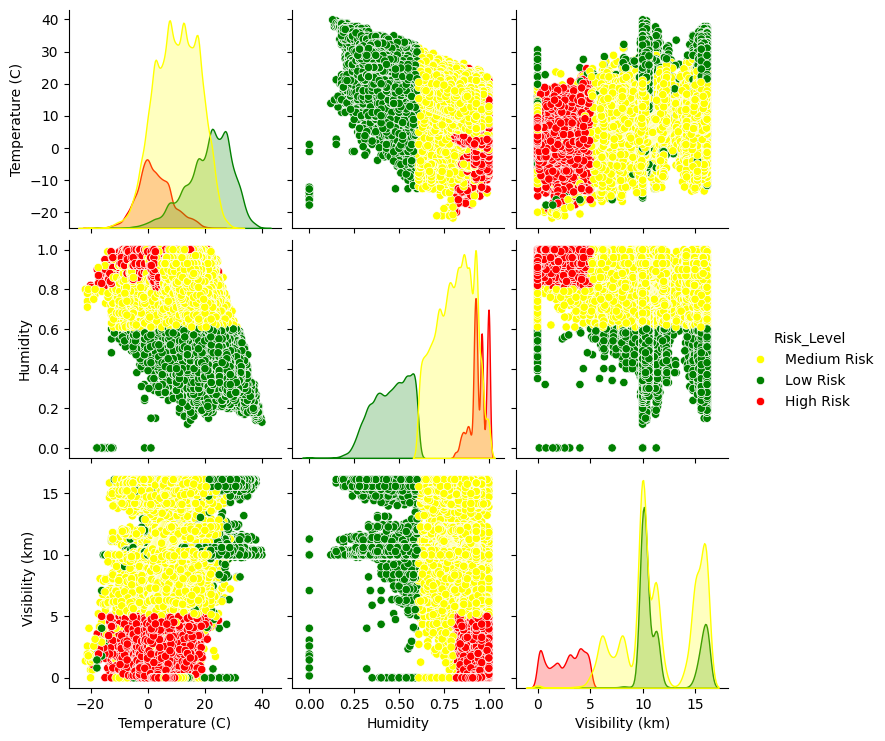

In [5]:
import seaborn as sns
import pandas as pd

# Load and prepare data if not already done
df = pd.read_csv("weatherHistory.csv")

# Create weather categories
def simplify_weather(summary):
    if "Cloudy" in summary or "Overcast" in summary:
        return "Cloudy"
    elif "Clear" in summary:
        return "Clear"
    elif "Foggy" in summary:
        return "Foggy"
    elif "Rain" in summary or "Drizzle" in summary:
        return "Rain"
    elif "Windy" in summary or "Breezy" in summary:
        return "Windy"
    else:
        return "Other"

df['Weather_Category'] = df['Summary'].apply(simplify_weather)

# Filter for clean data
df_clean = df[df['Weather_Category'].isin(['Cloudy', 'Clear', 'Foggy'])]

# Add risk level
def risk_level(row):
    if row['Humidity'] > 0.8 and row['Visibility (km)'] < 5:
        return "High Risk"
    elif row['Humidity'] > 0.6:
        return "Medium Risk"
    else:
        return "Low Risk"

df_clean['Risk_Level'] = df_clean.apply(risk_level, axis=1)

# Create pairplot
palette = {
    "High Risk": "red",
    "Medium Risk": "yellow",
    "Low Risk": "green"
}

sns.pairplot(
    df_clean[['Temperature (C)', 'Humidity', 'Visibility (km)', 'Risk_Level']],
    hue='Risk_Level',
    palette=palette
)

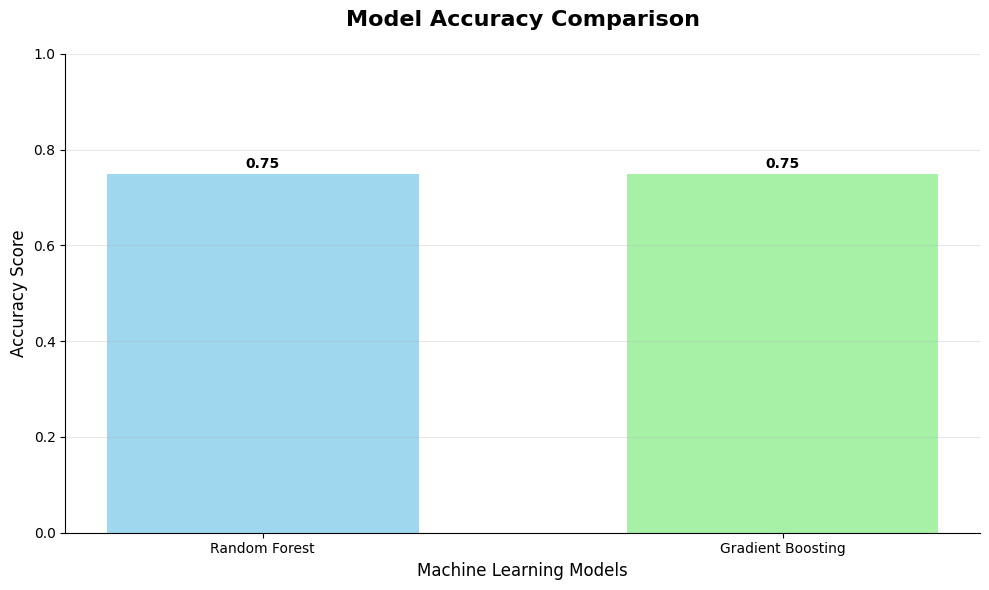

In [4]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Random Forest', 'Gradient Boosting']
accuracy = [0.75, 0.75]

# Create figure with better styling
fig, ax = plt.subplots(figsize=(10, 6))

# Create bars with different colors
bars = ax.bar(models, accuracy, color=['skyblue', 'lightgreen'], alpha=0.8, width=0.6)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
            f'{height:.2f}', ha='center', va='bottom', fontweight='bold')

# Customize the plot
ax.set_title("Model Accuracy Comparison", fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel("Accuracy Score", fontsize=12)
ax.set_xlabel("Machine Learning Models", fontsize=12)
ax.set_ylim(0, 1.0)  # Set y-axis from 0 to 1 for accuracy

# Add grid for better readability
ax.grid(axis='y', alpha=0.3)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [49]:
import pandas as pd

new_data = pd.DataFrame({
    'Temperature (C)': [25],
    'Wind Speed (km/h)': [10],
    'Pressure (millibars)': [1015]
})

prediction = model2.predict(new_data)

print("Predicted Risk Level:", prediction[0])

Predicted Risk Level: Low Risk


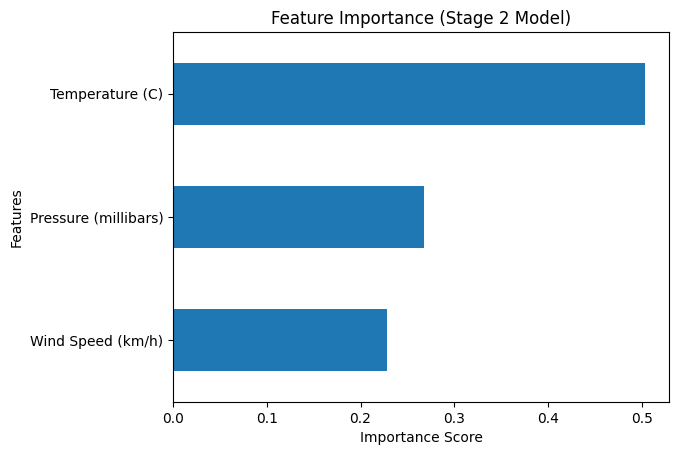

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

importances = model2.feature_importances_
feature_names = X_train2.columns

feat_imp = pd.Series(importances, index=feature_names).sort_values()

feat_imp.plot(kind='barh')
plt.title("Feature Importance (Stage 2 Model)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

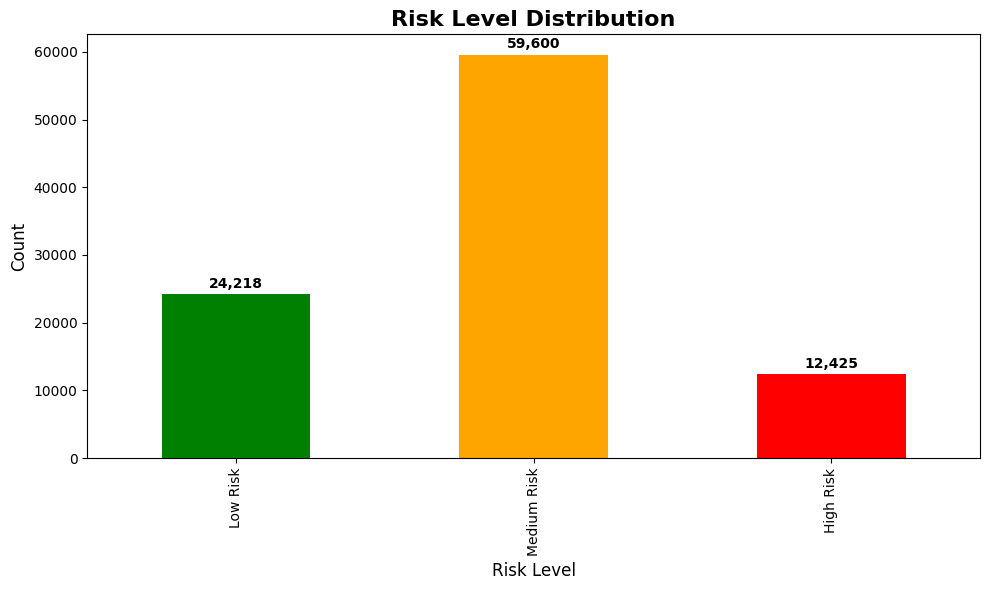

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load and prepare data if not already done
df = pd.read_csv("weatherHistory.csv")

# Create weather categories
def simplify_weather(summary):
    if "Cloudy" in summary or "Overcast" in summary:
        return "Cloudy"
    elif "Clear" in summary:
        return "Clear"
    elif "Foggy" in summary:
        return "Foggy"
    elif "Rain" in summary or "Drizzle" in summary:
        return "Rain"
    elif "Windy" in summary or "Breezy" in summary:
        return "Windy"
    else:
        return "Other"

df['Weather_Category'] = df['Summary'].apply(simplify_weather)

# Filter for clean data
df_clean = df[df['Weather_Category'].isin(['Cloudy', 'Clear', 'Foggy'])]

# Add risk level
def risk_level(row):
    if row['Humidity'] > 0.8 and row['Visibility (km)'] < 5:
        return "High Risk"
    elif row['Humidity'] > 0.6:
        return "Medium Risk"
    else:
        return "Low Risk"

df_clean['Risk_Level'] = df_clean.apply(risk_level, axis=1)

# Create custom color mapping
color_map = {
    'High Risk': 'red',
    'Medium Risk': 'orange',
    'Low Risk': 'green'
}

# Get value counts and sort by index for consistent ordering
risk_counts = df_clean['Risk_Level'].value_counts()
risk_counts = risk_counts.reindex(['Low Risk', 'Medium Risk', 'High Risk'])

# Create colors list in the same order as the data
colors = [color_map[risk] for risk in risk_counts.index]

# Plot with custom colors
ax = risk_counts.plot(kind='bar', color=colors, figsize=(10, 6))

plt.title("Risk Level Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Risk Level", fontsize=12)
plt.ylabel("Count", fontsize=12)

# Add value labels on bars
for i, v in enumerate(risk_counts.values):
    ax.text(i, v + 500, f'{v:,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [52]:
import pandas as pd

new_data = pd.DataFrame({
    'Temperature (C)': [25, 10, 30],
    'Wind Speed (km/h)': [10, 20, 5],
    'Pressure (millibars)': [1015, 1000, 1020]
})

predictions = model2.predict(new_data)

for i, pred in enumerate(predictions):
    print(f"Sample {i+1} → Predicted Risk Level: {pred}")

Sample 1 → Predicted Risk Level: Low Risk
Sample 2 → Predicted Risk Level: Medium Risk
Sample 3 → Predicted Risk Level: Low Risk


### Additional Analysis and Predictions

Feature importance analysis highlights the contribution of each input variable in predicting risk levels. It helps in understanding which factors influence the model most.

The risk distribution plot shows the imbalance in the dataset, where Medium Risk dominates, which explains better model performance for that class.

Finally, predictions on new unseen data demonstrate the practical applicability of the model in real-world scenarios.

In [53]:
import joblib
joblib.dump(model2, "model.pkl")

['model.pkl']